In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt



2025-07-13 20:14:30.159882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752430470.244892   25575 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752430470.268281   25575 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-13 20:14:30.452783: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32") / 255

train_images_w_noise = np.concatenate([train_images,  np.random.random((len(train_images), 784))], axis = 1)
train_images_w_zeros = np.concatenate([train_images,  np.zeros((len(train_images), 784))], axis = 1)

In [3]:
def get_model():
    model  = keras.Sequential([
        layers.Dense(512, activation = "relu"),
        layers.Dense(10, activation = "softmax"),
    ])
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

In [ ]:
model_noise = get_model()
history_noise = model_noise.fit(
    train_images_w_noise, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

model_zeros = get_model()
history_zeros = model_zeros.fit(
    train_images_w_zeros, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

I0000 00:00:1752430476.500097   25575 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6625 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1070, pci bus id: 0000:08:00.0, compute capability: 6.1


Epoch 1/10


I0000 00:00:1752430477.887774   25717 service.cc:148] XLA service 0x764850017f00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752430477.887815   25717 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
2025-07-13 20:14:37.933608: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752430478.030332   25717 cuda_dnn.cc:529] Loaded cuDNN version 90300


 94/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5173 - loss: 1.8473

I0000 00:00:1752430478.662423   25717 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7028 - loss: 1.0527 - val_accuracy: 0.9196 - val_loss: 0.2625
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9149 - loss: 0.2750 - val_accuracy: 0.9408 - val_loss: 0.1980
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9436 - loss: 0.1796 - val_accuracy: 0.9588 - val_loss: 0.1449
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9619 - loss: 0.1218 - val_accuracy: 0.9565 - val_loss: 0.1472
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9736 - loss: 0.0867 - val_accuracy: 0.9583 - val_loss: 0.1408
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9794 - loss: 0.0662 - val_accuracy: 0.9573 - val_loss: 0.1435
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.0487 - val_accuracy: 0.9156 - val_loss: 0.2763
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9888 - loss: 0.0343 - val_accuracy: 0.9619 - val_

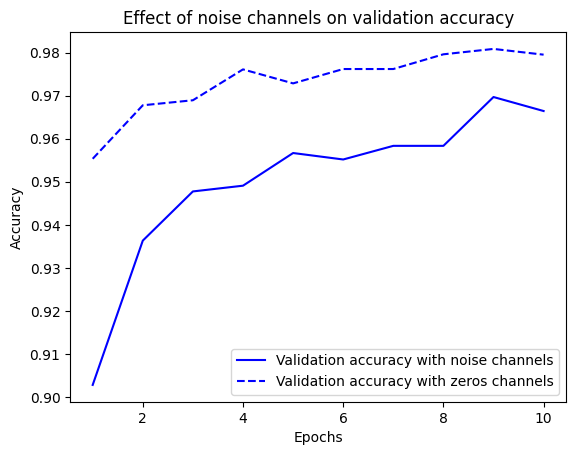

In [ ]:
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-", label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--", label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

In [ ]:
#Fitting an mnist model with randomly shuffled labels

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(train_images, random_train_labels,
          epochs=100,
          batch_size=128,
          validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1023 - loss: 2.3292 - val_accuracy: 0.1046 - val_loss: 2.3042
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1195 - loss: 2.2962 - val_accuracy: 0.1078 - val_loss: 2.3110
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1309 - loss: 2.2885 - val_accuracy: 0.1098 - val_loss: 2.3132
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1422 - loss: 2.2748 - val_accuracy: 0.1045 - val_loss: 2.3226
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1548 - loss: 2.2560 - val_accuracy: 0.1060 - val_loss: 2.3357
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1723 - loss: 2.2363 - val_accuracy: 0.1035 - val_loss: 2.3410
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1883 - loss: 2.2126 - val_accuracy: 0.1056 - val_loss: 2.3584
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2058 - loss: 2.1846 - val_accu

In [ ]:
# Training an mnist model with a dumb learning rate to cause numerical instability and mess everything up

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32") /255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer=keras.optimizers.RMSprop(1.),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4092 - loss: 2713.1655 - val_accuracy: 0.1849 - val_loss: 2.2647
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1945 - loss: 4.0082 - val_accuracy: 0.2511 - val_loss: 2.2756
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1923 - loss: 2.5082 - val_accuracy: 0.1765 - val_loss: 2.4103
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1756 - loss: 2.2996 - val_accuracy: 0.1768 - val_loss: 2.1952
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1698 - loss: 2.3885 - val_accuracy: 0.1600 - val_loss: 2.3709
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1744 - loss: 2.3406 - val_accuracy: 0.1777 - val_loss: 2.9620
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1944 - loss: 2.3728 - val_accuracy: 0.1501 - val_loss: 2.2622
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1680 - loss: 2.3977 - val_accuracy:

In [ ]:
# Same thing but with a better learning rate

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32") /255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer=keras.optimizers.RMSprop(1e-2),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8398 - loss: 0.9098 - val_accuracy: 0.9528 - val_loss: 0.1727
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9624 - loss: 0.1297 - val_accuracy: 0.9627 - val_loss: 0.1458
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0916 - val_accuracy: 0.9686 - val_loss: 0.1387
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9808 - loss: 0.0734 - val_accuracy: 0.9727 - val_loss: 0.1436
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0662 - val_accuracy: 0.9701 - val_loss: 0.1829
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9878 - loss: 0.0478 - val_accuracy: 0.9758 - val_loss: 0.1625
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.0422 - val_accuracy: 0.9749 - val_loss: 0.1776
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9901 - loss: 0.0443 - val_accuracy: 0.

In [ ]:
# Having a model that trains and generalizes but can't overfit

model = keras.Sequential([layers.Dense(10, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7434 - loss: 1.0255 - val_accuracy: 0.9001 - val_loss: 0.3630
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8988 - loss: 0.3670 - val_accuracy: 0.9132 - val_loss: 0.3098
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9102 - loss: 0.3288 - val_accuracy: 0.9189 - val_loss: 0.2926
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9132 - loss: 0.3054 - val_accuracy: 0.9219 - val_loss: 0.2830
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9192 - loss: 0.2909 - val_accuracy: 0.9221 - val_loss: 0.2787
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9202 - loss: 0.2863 - val_accuracy: 0.9258 - val_loss: 0.2739
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9209 - loss: 0.2834 - val_accuracy: 0.9276 - val_loss: 0.2725
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9226 - loss: 0.2774 - val_accuracy: 0.

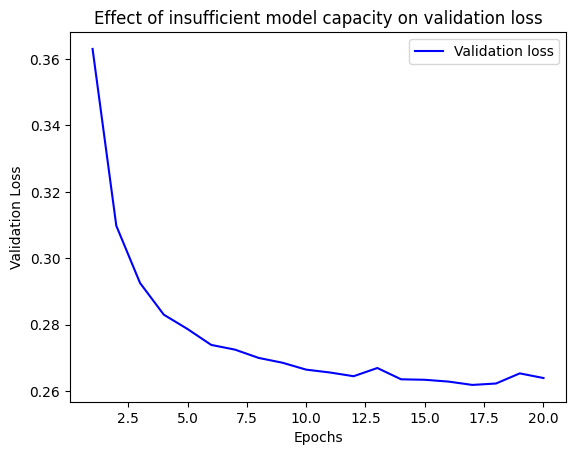

In [ ]:
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()

In [ ]:
# Do the same thing but with a bigger model (more representational capacity if  you want to sound fancy)
model = keras.Sequential([layers.Dense(96, activation="relu"),
                          layers.Dense(96, activation="relu"),
                          layers.Dense(10, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8296 - loss: 0.6191 - val_accuracy: 0.9487 - val_loss: 0.1781
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9498 - loss: 0.1711 - val_accuracy: 0.9588 - val_loss: 0.1373
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9665 - loss: 0.1144 - val_accuracy: 0.9686 - val_loss: 0.1092
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9747 - loss: 0.0858 - val_accuracy: 0.9718 - val_loss: 0.0957
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9801 - loss: 0.0662 - val_accuracy: 0.9723 - val_loss: 0.1019
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9837 - loss: 0.0543 - val_accuracy: 0.9742 - val_loss: 0.0921
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9856 - loss: 0.0466 - val_accuracy: 0.9727 - val_loss: 0.0952
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9888 - loss: 0.0350 - val_accuracy: 0.

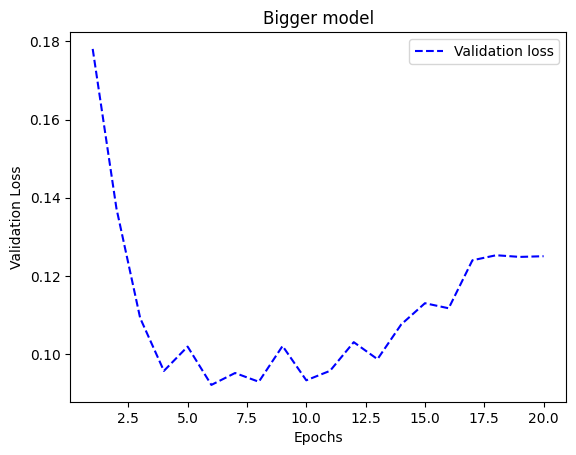

In [ ]:
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--", label="Validation loss")
plt.title("Bigger model")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()

In [ ]:
for x in range(1,3):
    print(x)


1
2


# Regularizing a model
Lowering model capacity to prevent overfitting:

In [ ]:
from tensorflow.keras.datasets import imdb


#imdb dataset: each review is a set of strings. Each word in the string has been indexed as integers
#we only use the 10k most used words
#labes: 1 if review is positive, 0 if negative
(movie_train_data, movie_train_labels), (movie_test_data, movie_test_labels) = imdb.load_data(num_words = 10000)

word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(         #"?"" if the word isn't in the top 10k
    [reverse_word_index.get(i - 3,  "?") for i in movie_train_data[0]])

print(f"Decoded review: {decoded_review}")

#multi hot encoding: turn a vector of strings into a vector of 1s and 0s. each entry in the vector corresponds to a word.
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1
    return results


movie_model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

movie_model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

movie_history = movie_model.fit(movie_train_data, movie_train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=0.4)

small_movie_model = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

small_movie_model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

small_movie_history = small_movie_model.fit(movie_train_data, movie_train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=0.4)



Decoded review: ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have do

ValueError: Invalid dtype: object